# Imports and Setup

In [48]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Add, Dense, Activation, BatchNormalization, Conv2D, AveragePooling2D, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import math
import numpy as np
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

import os

In [49]:
print("Num GPUs Available:", len(tf.config.experimental.list_physical_devices('GPU')))

Num GPUs Available: 1


In [51]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Hides INFO logs but keeps important warnings

In [62]:
# Define constants
TFRECORD_FILE = "shared/filtered_emnist.tfrecord"

BATCH_SIZE = 64
IMG_SIZE = (28, 28)
NUM_CLASSES = 36  # Digits (0-9) + Uppercase Letters (A-Z)
EPOCHS = 20

TOTAL_SAMPLES = 533993
TRAIN_RATIO = 0.8
TRAIN_SIZE = int(TOTAL_SAMPLES * TRAIN_RATIO)
VAL_SIZE = TOTAL_SAMPLES - TRAIN_SIZE

# Label dictionary
label_dict = {
    0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9',
    10: 'A', 11: 'B', 12: 'C', 13: 'D', 14: 'E', 15: 'F', 16: 'G', 17: 'H', 18: 'I', 19: 'J',
    20: 'K', 21: 'L', 22: 'M', 23: 'N', 24: 'O', 25: 'P', 26: 'Q', 27: 'R', 28: 'S', 29: 'T',
    30: 'U', 31: 'V', 32: 'W', 33: 'X', 34: 'Y', 35: 'Z'
}

# Helper Functions

In [53]:
def visualize_dataset_samples(dataset, num_samples=20):
    """
    Visualizes a few data samples from the dataset.

    Args:
        dataset (tf.data.Dataset): The dataset containing image-label pairs.
        label_dict (dict): Dictionary mapping label indices to characters.
        num_samples (int): Number of samples to visualize (default: 20).
    """
    plt.figure(figsize=(12, 8))

    # Calculate rows and columns for subplots dynamically
    cols = 5
    rows = math.ceil(num_samples / cols)

    for i, (image, label) in enumerate(dataset.take(num_samples)):
        label_np = label.numpy()

        # Check if the label is one-hot encoded (array) or a single integer
        if label_np.ndim > 0 and len(label_np) > 1:
            label_index = np.argmax(label_np)  # Convert one-hot encoding to class index
        else:
            label_index = int(label_np)  # Use integer directly

        label_char = label_dict[label_index]  # Get character label

        plt.subplot(rows, cols, i + 1)
        plt.imshow(image.numpy())
        plt.title(f'Label: {label_char} (Index: {label_index})', fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Load Data

In [58]:
# Function to parse TFRecord file
def _parse_function(proto):
    keys_to_features = {
        "image": tf.io.FixedLenFeature([], tf.string),
        "label": tf.io.FixedLenFeature([1], tf.int64)
    }
    parsed_features = tf.io.parse_single_example(proto, keys_to_features)
    image = tf.image.decode_jpeg(parsed_features["image"])
    label = parsed_features["label"][0]

    return image, label

# Load dataset
dataset = tf.data.TFRecordDataset(TFRECORD_FILE).map(_parse_function)

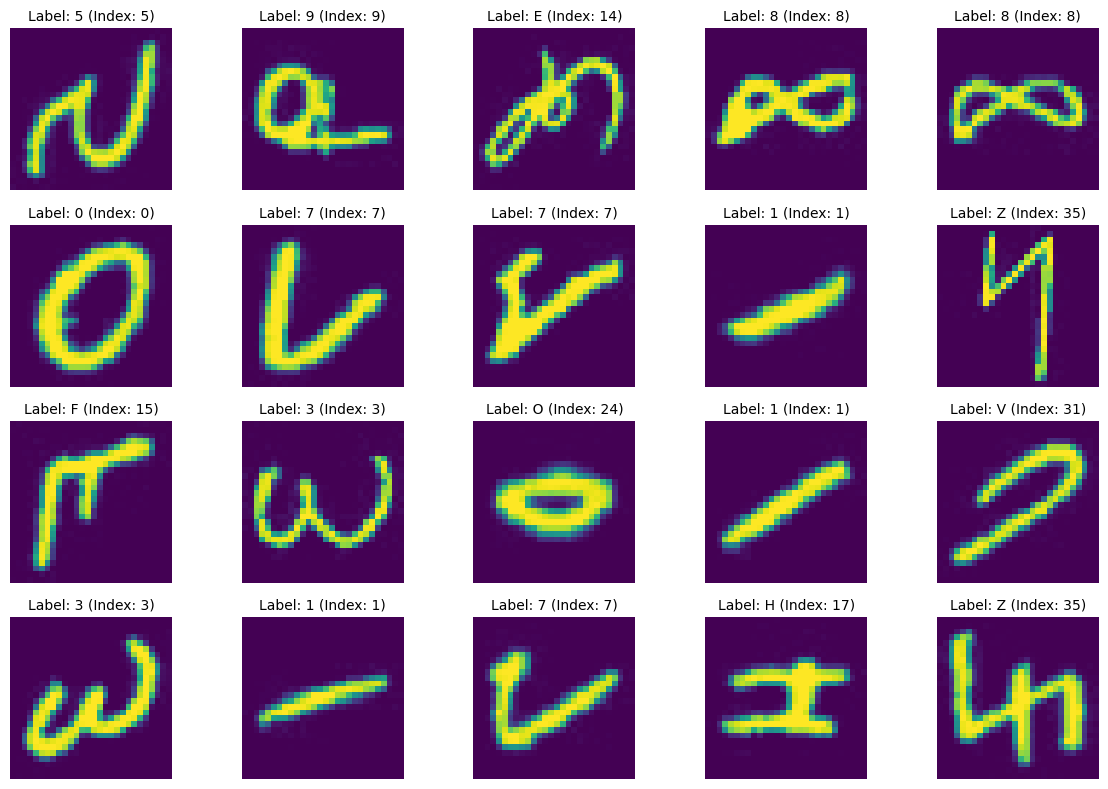

In [55]:
visualize_dataset_samples(dataset, num_samples=20)

# Data Preprocessing

In [59]:
# Preprocess function: reshape, normalize, one-hot encode
def preprocess_data(image, label):
    image = tf.image.resize(image, IMG_SIZE) / 255.0  # Normalize pixel values
    label = tf.one_hot(label, NUM_CLASSES)  # One-hot encode labels
    return image, label

# Augmentation function
def augment_image(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    return image, label

# Preprocess data
dataset = dataset.map(preprocess_data)

# Split data into train and validation sets
dataset = dataset.shuffle(1000)  # Shuffle before splitting

# Apply augmentation to train dataset
train_dataset = dataset.take(TRAIN_SIZE).map(augment_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset = dataset.skip(TRAIN_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

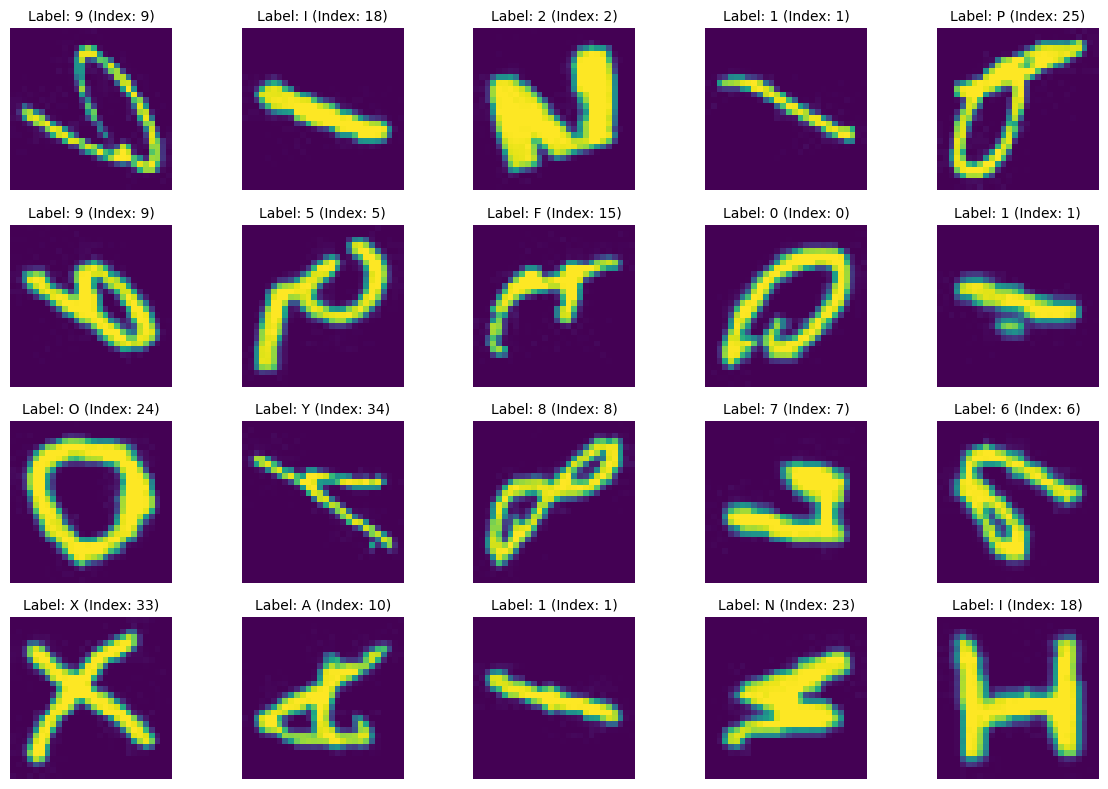

In [60]:
visualize_dataset_samples(train_dataset.unbatch(), num_samples=20)

# Create Resnet18 Model

In [61]:
def identity_block(x, filters, block_name):
    """Identity block for ResNet18."""
    x_shortcut = x

    # First convolution
    x = Conv2D(filters, (3, 3), padding="same", name=f"{block_name}_conv1")(x)
    x = BatchNormalization(name=f"{block_name}_bn1")(x)
    x = Activation("relu", name=f"{block_name}_relu1")(x)

    # Second convolution
    x = Conv2D(filters, (3, 3), padding="same", name=f"{block_name}_conv2")(x)
    x = BatchNormalization(name=f"{block_name}_bn2")(x)

    # Skip connection
    x = Add(name=f"{block_name}_add")([x, x_shortcut])
    x = Activation("relu", name=f"{block_name}_relu2")(x)

    return x

def convolutional_block(x, filters, strides=(2, 2), block_name="conv_block"):
    """Residual block with downsampling."""
    x_shortcut = Conv2D(filters, (1, 1), strides=strides, padding="same", name=f"{block_name}_shortcut")(x)
    x_shortcut = BatchNormalization(name=f"{block_name}_bn_shortcut")(x_shortcut)

    # First convolution (applies stride)
    x = Conv2D(filters, (3, 3), strides=strides, padding="same", name=f"{block_name}_conv1")(x)
    x = BatchNormalization(name=f"{block_name}_bn1")(x)
    x = Activation("relu", name=f"{block_name}_relu1")(x)

    # Second convolution (no stride)
    x = Conv2D(filters, (3, 3), padding="same", name=f"{block_name}_conv2")(x)
    x = BatchNormalization(name=f"{block_name}_bn2")(x)

    # Skip connection
    x = Add(name=f"{block_name}_add")([x, x_shortcut])
    x = Activation("relu", name=f"{block_name}_relu2")(x)

    return x

def ResNet18(input_shape=(28, 28, 1), num_classes=NUM_CLASSES):
    inputs = Input(shape=input_shape, name="input_layer")

    # Initial Conv Layer
    x = Conv2D(64, (5, 5), strides=2, padding="same", activation="relu", name="initial_conv")(inputs)
    x = BatchNormalization(name="initial_bn")(x)
    x = MaxPooling2D((3, 3), strides=2, padding="same", name="initial_pool")(x)

    # ResNet Blocks
    x = identity_block(x, 64, block_name="block1_1")
    x = identity_block(x, 64, block_name="block1_2")

    x = convolutional_block(x, 128, block_name="block2_1")  # Downsampling here
    x = identity_block(x, 128, block_name="block2_2")

    x = convolutional_block(x, 256, block_name="block3_1")  # Downsampling here
    x = identity_block(x, 256, block_name="block3_2")

    x = convolutional_block(x, 512, block_name="block4_1")  # Downsampling here
    x = identity_block(x, 512, block_name="block4_2")

    # Classification Head
    x = GlobalAveragePooling2D(name="global_avg_pool")(x)
    outputs = Dense(num_classes, activation="softmax", name="output_layer")(x)

    model = Model(inputs, outputs, name="ResNet18")
    return model

# Build model
model = ResNet18()

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

# Summarize model
model.summary()

Model: "ResNet18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_conv        │ (None, 14, 14,    │      1,664 │ input_layer[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_bn          │ (None, 14, 14,    │        256 │ initial_conv[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_pool        │ (None, 7, 7, 64)  │          0 │ initial_bn[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_conv1      │ (None, 7, 7, 64)  │     36,928 │ initial_pool[0][… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_bn1        │ (None, 7, 7, 64)  │        256 │ block1_1_conv1[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_relu1      │ (None, 7, 7, 64)  │          0 │ block1_1_bn1[0][… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_conv2      │ (None, 7, 7, 64)  │     36,928 │ block1_1_relu1[0… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_bn2        │ (None, 7, 7, 64)  │        256 │ block1_1_conv2[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_add (Add)  │ (None, 7, 7, 64)  │          0 │ block1_1_bn2[0][… │
│                     │                   │            │ initial_pool[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_relu2      │ (None, 7, 7, 64)  │          0 │ block1_1_add[0][… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_conv1      │ (None, 7, 7, 64)  │     36,928 │ block1_1_relu2[0… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_bn1        │ (None, 7, 7, 64)  │        256 │ block1_2_conv1[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_relu1      │ (None, 7, 7, 64)  │          0 │ block1_2_bn1[0][… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_conv2      │ (None, 7, 7, 64)  │     36,928 │ block1_2_relu1[0… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_bn2        │ (None, 7, 7, 64)  │        256 │ block1_2_conv2[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_add (Add)  │ (None, 7, 7, 64)  │          0 │ block1_2_bn2[0][

 Total params: 11,201,572 (42.73 MB)

 Trainable params: 11,191,972 (42.69 MB)

 Non-trainable params: 9,600 (37.50 KB)

# Train Model

In [63]:
# Checkpoint to save the best model
model_checkpoint = ModelCheckpoint('checkpoints/resnet18.keras', monitor='val_accuracy', mode='max', save_best_only=True, verbose=1)

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Reduce learning rate when validation loss plateaus
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',  # Watch validation loss
    factor=0.5,          # Reduce LR by half
    patience=3,          # Wait 3 epochs before reducing
    verbose=1,           # Print updates
    min_lr=1e-6          # Set a lower bound for LR
)

# Train the model
model_history = model.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS, callbacks=[model_checkpoint, lr_scheduler, early_stopping])

Epoch 1/20
   6675/Unknown 144s 18ms/step - accuracy: 0.8074 - loss: 0.6111

/home/jovyan/.local/lib/python3.9/site-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_accuracy improved from -inf to 0.90392, saving model to checkpoints/resnet18.keras
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 180s 24ms/step - accuracy: 0.8074 - loss: 0.6111 - val_accuracy: 0.9039 - val_loss: 0.2585 - learning_rate: 1.0000e-04
Epoch 2/20
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9042 - loss: 0.2623
Epoch 2: val_accuracy improved from 0.90392 to 0.91206, saving model to checkpoints/resnet18.keras
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 152s 23ms/step - accuracy: 0.9042 - loss: 0.2623 - val_accuracy: 0.9121 - val_loss: 0.2315 - learning_rate: 1.0000e-04
Epoch 3/20
6673/6675 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9146 - loss: 0.2280

2025-02-19 02:05:20.766782: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 12874478065230330645



Epoch 3: val_accuracy improved from 0.91206 to 0.91851, saving model to checkpoints/resnet18.keras


...

6675/6675 ━━━━━━━━━━━━━━━━━━━━ 151s 23ms/step - accuracy: 0.9405 - loss: 0.1465 - val_accuracy: 0.9317 - val_loss: 0.1798 - learning_rate: 5.0000e-05
Epoch 12/20
6672/6675 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9422 - loss: 0.1426

2025-02-19 02:27:50.567960: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 12874478065230330645



Epoch 12: val_accuracy did not improve from 0.93168
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 147s 22ms/step - accuracy: 0.9422 - loss: 0.1426 - val_accuracy: 0.9297 - val_loss: 0.1885 - learning_rate: 5.0000e-05
Epoch 13/20
6673/6675 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9437 - loss: 0.1376
Epoch 13: val_accuracy did not improve from 0.93168
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 149s 22ms/step - accuracy: 0.9437 - loss: 0.1376 - val_accuracy: 0.9313 - val_loss: 0.1846 - learning_rate: 5.0000e-05
Epoch 14/20
6674/6675 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9450 - loss: 0.1340
Epoch 14: val_accuracy improved from 0.93168 to 0.93290, saving model to checkpoints/resnet18.keras

Epoch 14: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 153s 23ms/step - accuracy: 0.9450 - loss: 0.1340 - val_accuracy: 0.9329 - val_loss: 0.1807 - learning_rate: 5.0000e-05
Epoch 15/20
6672/6675 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9476 - loss: 0.12

2025-02-19 02:37:54.421701: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 12874478065230330645



Epoch 16: val_accuracy improved from 0.93290 to 0.93351, saving model to checkpoints/resnet18.keras
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 154s 23ms/step - accuracy: 0.9491 - loss: 0.1214 - val_accuracy: 0.9335 - val_loss: 0.1842 - learning_rate: 2.5000e-05


# Evaluate Model

In [64]:
def plot_accuracy_loss(model_history):
    """
    Plots model training history for accuracy and loss with consistent epoch handling.
    """
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Dynamically find available keys
    history_keys = model_history.history.keys()

    # Extract metrics, handling missing keys
    accuracy = next((model_history.history[key] for key in history_keys if "accuracy" in key and "val" not in key), [])
    val_accuracy = next((model_history.history[key] for key in history_keys if "val_accuracy" in key), [])
    loss = model_history.history.get("loss", [])
    val_loss = model_history.history.get("val_loss", [])

    epochs = range(1, len(accuracy) + 1)

    # Accuracy subplot
    ax[0].plot(epochs, accuracy, label="Training Accuracy", marker="o")
    ax[0].plot(epochs, val_accuracy, label="Validation Accuracy", marker="s")
    ax[0].set_title("Model Accuracy")
    ax[0].set_xlabel("Epochs")
    ax[0].set_ylabel("Accuracy")
    ax[0].set_xticks(epochs)
    ax[0].legend()
    ax[0].grid(True, linestyle="--", alpha=0.6)

    # Loss subplot
    ax[1].plot(epochs, loss, label="Training Loss", marker="o")
    ax[1].plot(epochs, val_loss, label="Validation Loss", marker="s")
    ax[1].set_title("Model Loss")
    ax[1].set_xlabel("Epochs")
    ax[1].set_ylabel("Loss")
    ax[1].set_xticks(epochs)
    ax[1].legend()
    ax[1].grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()

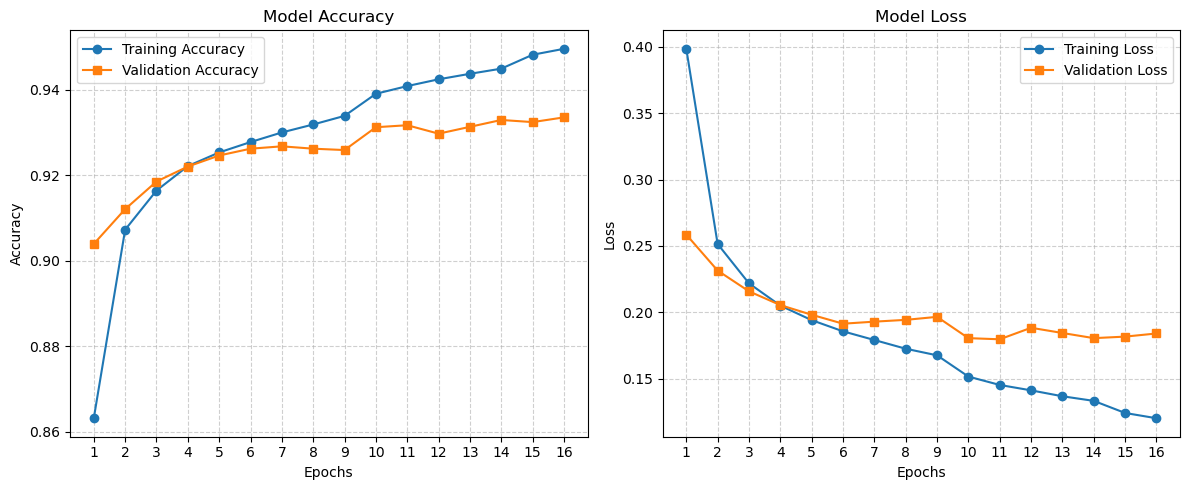

In [65]:
plot_accuracy_loss(model_history)

In [73]:
def extract_predictions(model, dataset, num_samples=9):
    """
    Extracts true labels and predicted labels from the dataset.
    
    Args:
        model (tf.keras.Model): Trained model.
        dataset (tf.data.Dataset): Dataset containing images and labels.
        num_samples (int): Number of sample images to store for visualization.
    
    Returns:
        y_true (np.array): True labels.
        y_pred (np.array): Predicted labels.
        sample_images (list): A few sample images.
        sample_labels (list): True labels of the sample images.
        sample_preds (list): Predicted labels of the sample images.
    """
    y_true = []
    y_pred = []
    sample_images = []
    sample_labels = []
    sample_preds = []

    for images, labels in dataset:
        # Convert one-hot encoded labels to class indices
        y_true.append(np.argmax(labels, axis=1))
        preds = model.predict(images, verbose=0)
        y_pred.append(np.argmax(preds, axis=1))

        # Store a few sample images with predictions
        if len(sample_images) < num_samples:
            for i in range(min(len(images), num_samples - len(sample_images))):
                sample_images.append(images[i].numpy())
                sample_labels.append(np.argmax(labels[i].numpy()))
                sample_preds.append(np.argmax(preds[i]))

    # Concatenate all batches into single arrays
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    return y_true, y_pred, sample_images, sample_labels, sample_preds


def compute_metrics(y_true, y_pred, class_names):
    """
    Computes precision, recall, F1-score, and displays the confusion matrix.
    
    Args:
        y_true (np.array): True labels.
        y_pred (np.array): Predicted labels.
        class_names (dict): Dictionary mapping label indices to characters.
    """
    # Compute precision, recall, and F1-score
    precision = precision_score(y_true, y_pred, average="macro", zero_division=1)
    recall = recall_score(y_true, y_pred, average="macro", zero_division=1)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=1)

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plot confusion matrix
    plt.figure(figsize=(16, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                xticklabels=[class_names[i] for i in sorted(class_names.keys())],
                yticklabels=[class_names[i] for i in sorted(class_names.keys())])
    plt.title('Confusion Matrix', fontsize=18)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.ylabel('True Label', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


def display_sample_predictions(sample_images, sample_labels, sample_preds, class_names, num_samples=9):
    """
    Displays a few sample predictions with corresponding images.
    
    Args:
        sample_images (list): List of sample images.
        sample_labels (list): List of true labels.
        sample_preds (list): List of predicted labels.
        class_names (dict): Dictionary mapping label indices to characters.
        num_samples (int): Number of images to display.
    """
    plt.figure(figsize=(12, 12))
    for i in range(num_samples):
        plt.subplot(9, 6, i + 1)
        plt.imshow(sample_images[i].squeeze())
        plt.title(f"Pred: {class_names[sample_preds[i]]} (Index: {sample_preds[i]})\n"
                  f"True: {class_names[sample_labels[i]]} (Index: {sample_labels[i]})")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [67]:
y_true, y_pred, sample_images, sample_labels, sample_preds = extract_predictions(model, val_dataset, 27)

Precision: 0.9370
Recall: 0.9284
F1-score: 0.9306


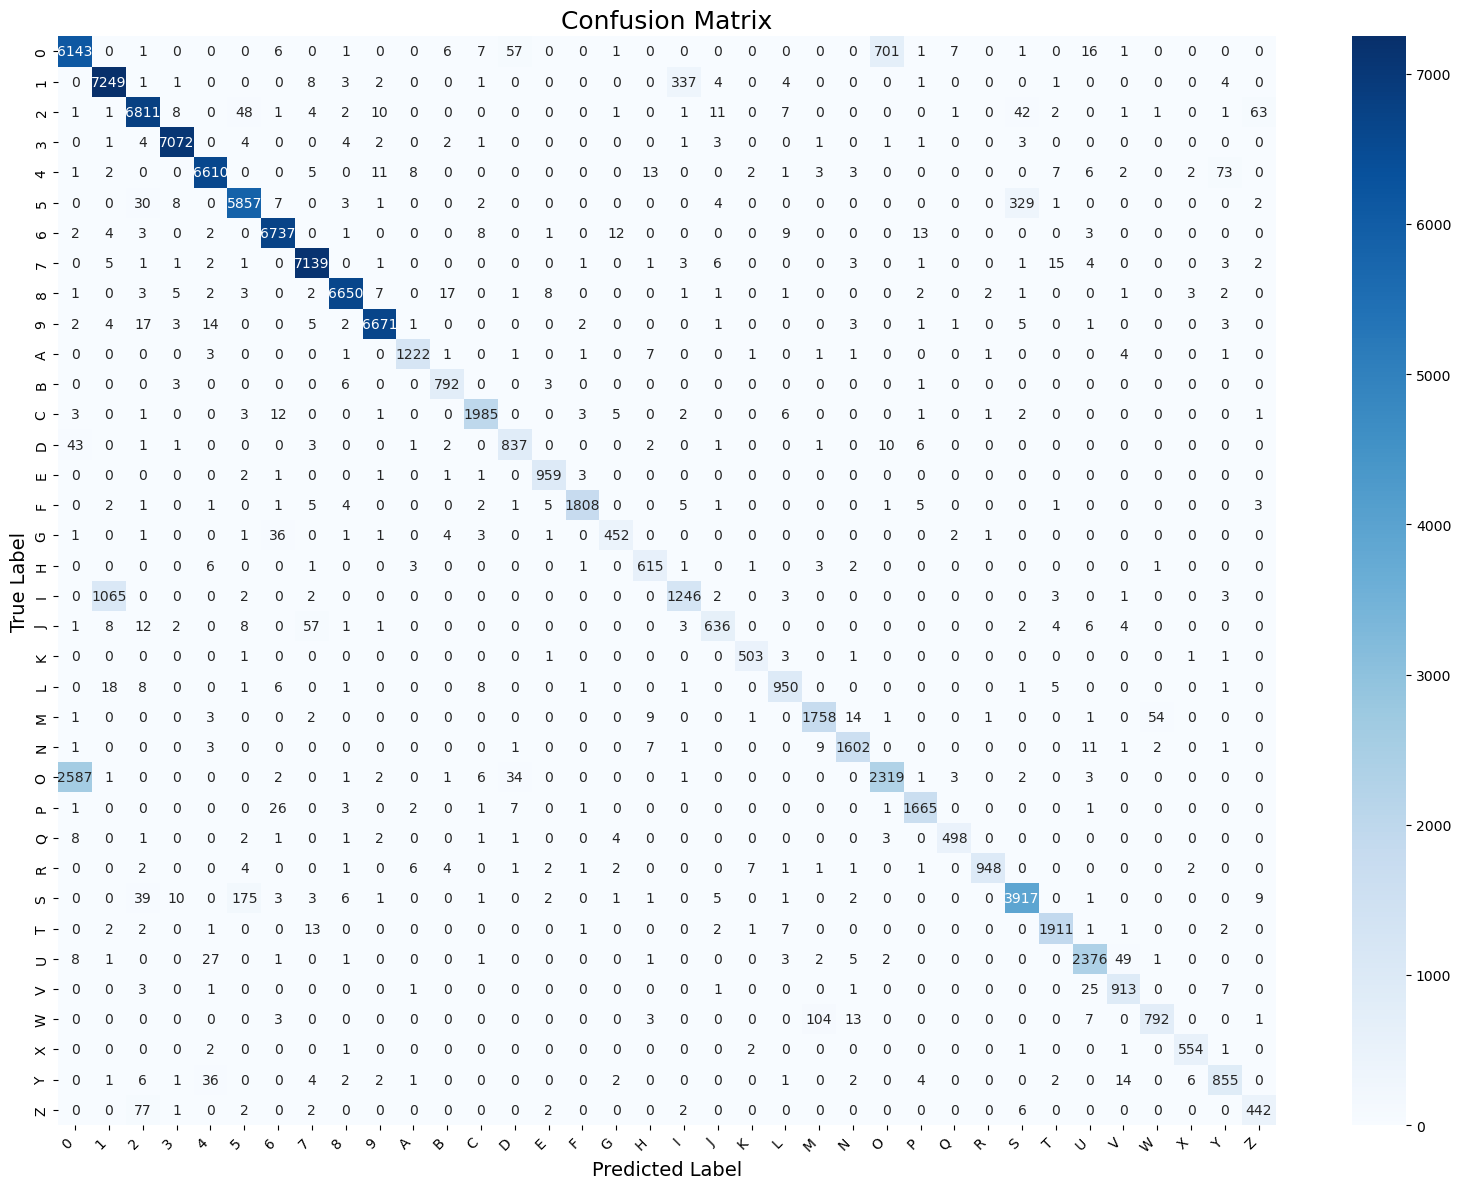

In [74]:
compute_metrics(y_true, y_pred, label_dict)

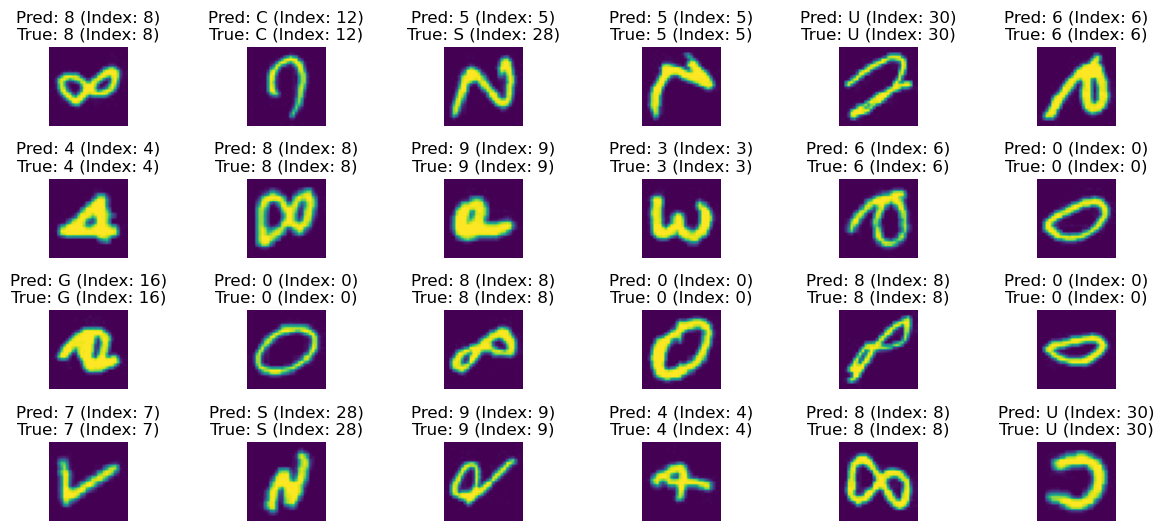

In [76]:
display_sample_predictions(sample_images, sample_labels, sample_preds, label_dict, 24)